# KNN Regression

## Importing Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("darkgrid")

In [2]:
df = pd.read_csv("../../Datasets/train_v9rqX0R.csv")
df_original = df.copy()
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Data Preprocessing

In [4]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

### Filling Nulls with mean and mode

In [5]:
mean = df['Item_Weight'].mean()
df.fillna({'Item_Weight': mean}, inplace=True)

mode = df['Outlet_Size'].mode()[0]
df.fillna({'Outlet_Size': mode}, inplace=True)

In [6]:
df.drop(columns=['Item_Identifier', 'Outlet_Identifier'], inplace=True, axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   object 
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   object 
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                8523 non-null   object 
 7   Outlet_Location_Type       8523 non-null   object 
 8   Outlet_Type                8523 non-null   object 
 9   Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 666.0+ KB


### Applying Onehot Encoder

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first')
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data.toarray(), columns=encoder.get_feature_names_out(categorical_cols), index=df.index)
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

In [9]:
display(df)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,Item_Type_Breads,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0.016047,249.8092,1999,3735.1380,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5.920,0.019278,48.2692,2009,443.4228,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,17.500,0.016760,141.6180,1999,2097.2700,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,19.200,0.000000,182.0950,1998,732.3800,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,8.930,0.000000,53.8614,1987,994.7052,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0.056783,214.5218,1987,2778.3834,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
8519,8.380,0.046982,108.1570,2002,549.2850,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
8520,10.600,0.035186,85.1224,2004,1193.1136,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
8521,7.210,0.145221,103.1332,2009,1845.5976,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


## Splitting the Dataset

In [10]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=3242)

x_train = train.drop(columns='Item_Outlet_Sales')
y_train = train['Item_Outlet_Sales']

x_test = test.drop(columns='Item_Outlet_Sales')
y_test = test['Item_Outlet_Sales']

## Applying RobustScaler

In [11]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Training the Model

In [12]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error, r2_score
import joblib

class knn_regressor:
    def __init__(self, x_train, y_train, x_test, y_test, k):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.k = k
        
        knn = neighbors.KNeighborsRegressor(n_neighbors=self.k, n_jobs=-1)
        knn.fit(self.x_train, self.y_train)
        
        self.y_pred = knn.predict(self.x_test)
        
        self.mse = mean_squared_error(self.y_test, self.y_pred)
        self.r2 = r2_score(self.y_test, self.y_pred)

    def getmetrics(self):
        return self.k, self.y_pred, self.mse, self.r2

In [13]:
k_list = range(1, 51)
train_df = pd.DataFrame(columns=['k', 'y_pred', 'MSE', 'R2', 'RMSE'])

trained_models = joblib.Parallel(n_jobs=-1, verbose=1)(
    joblib.delayed(knn_regressor)(x_train, y_train, x_test, y_test, k) for k in k_list
)

for model in trained_models:
    K, y_pred, mse, r2 = model.getmetrics()
    rmse = np.sqrt(mse)
    train_df = pd.concat([train_df, pd.DataFrame([[K, y_pred, mse, r2, rmse]], columns=['k', 'y_pred', 'MSE', 'R2', 'RMSE'])], ignore_index=True)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    7.4s finished
/tmp/ipykernel_39274/2130089521.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat([train_df, pd.DataFrame([[K, y_pred, mse, r2, rmse]], columns=['k', 'y_pred', 'MSE', 'R2', 'RMSE'])], ignore_index=True)


In [14]:
display(train_df)

,k,y_pred,MSE,R2,RMSE
0,1,"[1984.084, 3585.333, 2664.5316, 503.3448, 2976...",2.444719e+06,0.126951,1563.559849
1,2,"[2696.4900000000002, 2976.126, 2518.0555999999...",1.813110e+06,0.352509,1346.517636
2,3,"[2784.3756, 3763.7674, 2195.364533333333, 688....",1.652279e+06,0.409944,1285.409880
3,4,"[2591.6265, 3335.49155, 1905.8524999999997, 71...",1.559442e+06,0.443098,1248.776167
4,5,"[2836.308, 3090.2441200000003, 1609.7712399999...",1.512480e+06,0.459869,1229.829081
5,6,"[2874.9244, 2617.5927, 1398.4019333333333, 708...",1.500670e+06,0.464086,1225.018357
6,7,"[2558.6693999999998, 2685.3616285714284, 1274....",1.474344e+06,0.473488,1214.225592
7,8,"[2345.1972750000004, 2912.9582250000003, 1308....",1.462829e+06,0.477600,1209.474663
8,9,"[2401.170711111112, 2947.644555555556, 1320.42...",1.453442e+06,0.480952,1205.587801
9,10,"[2426.7078400000005, 2784.3756000000003, 1352....",1.438516e+06,0.486282,1199.381609


## Plotting Outputs

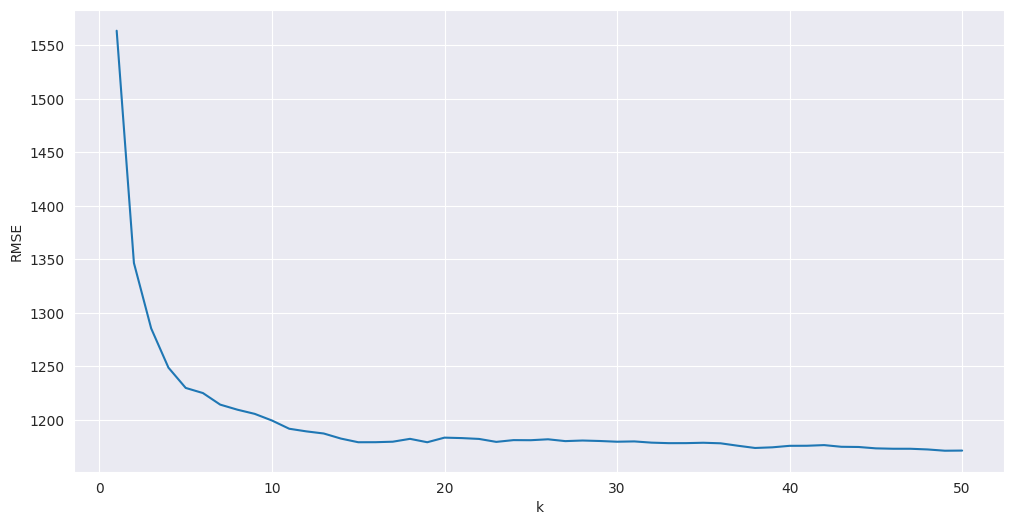

In [16]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_df, x='k', y='RMSE')
plt.show()

## Plotting the Pairplot

<Figure size 1200x600 with 0 Axes>

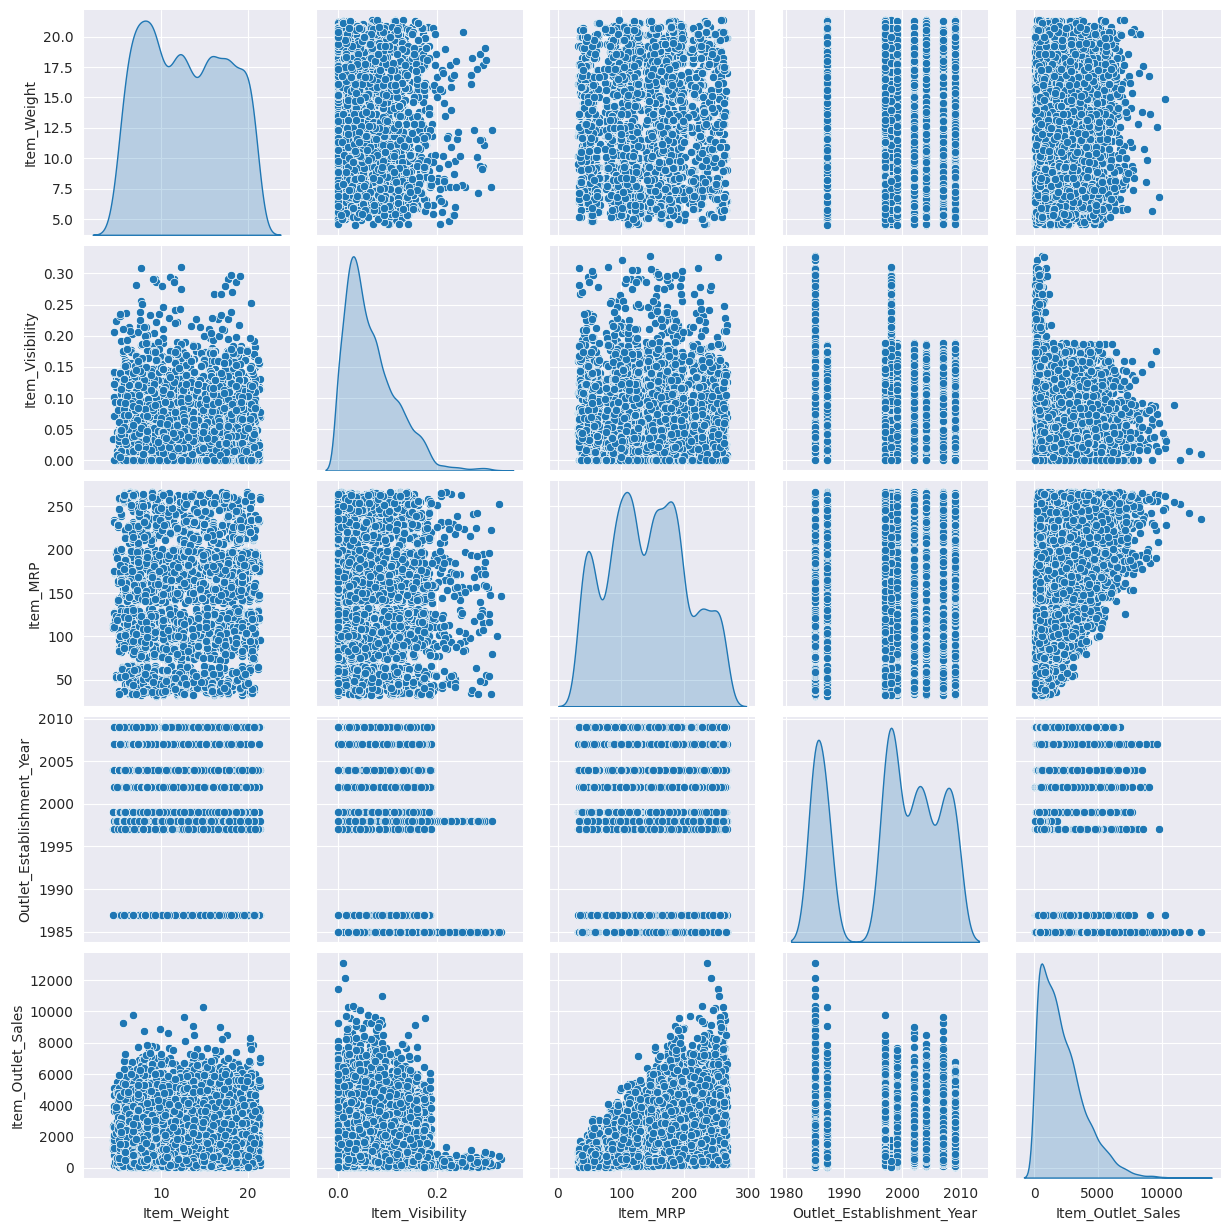

In [15]:
plt.figure(figsize=(12, 6))
sns.pairplot(df_original, diag_kind='kde')
plt.show()